In [1]:
import librosa
import os
from glob import glob
import numpy as np
data_path=r"C:\Users\User\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1"
train_data=[]
test_data=[]
for actor in os.listdir(data_path):
    if actor.startswith("Actor"):
     actor_num=int(actor.split("_")[1])
     actor_path=os.path.join(data_path,actor,"*.wav")
     file=glob(actor_path)
     if actor_num<=20:
        train_data.extend(file)
     else:
        test_data.extend(file)
print("length of train data",len(train_data))
print("length of test_data",len(test_data))


length of train data 1200
length of test_data 240


In [10]:
X=[]
Y=[]
def extract_features(data):
    for file in data:
        y,sr=librosa.load(file)
        mfcc=librosa.feature.mfcc(y=y,sr=sr,n_mfcc=40)
        mfcc=np.mean(mfcc.T,axis=0)
        emotion=int(os.path.basename(file).split('-')[2])-1
        X.append(mfcc)
        Y.append(emotion) 
    return np.array(X),np.array(Y)
    
X_train,Y_train=extract_features(train_data)
X_test,Y_test=extract_features(test_data)
np.save("X_test.npy", X_test)

In [3]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print("Final X_train shape:", X_train.shape)

Final X_train shape: (1200, 40, 1)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
model=models.Sequential([layers.Conv1D(256,5,padding='same',activation='relu',input_shape=(40,1)),
                         layers.BatchNormalization(),
                         layers.MaxPooling1D(pool_size=5),
                         layers.Dropout(0.2),

                         layers.Conv1D(128,5,padding='same',activation='relu'),
                         layers.BatchNormalization(),
                         layers.MaxPooling1D(pool_size=5),
                         layers.Dropout(0.2),

                         layers.Conv1D(64,5,padding='same',activation='relu'),
                         layers.BatchNormalization(),
                         layers.Dropout(0.2),
                         layers.Flatten(),
                         layers.Dense(64,activation='relu'),
                         layers.BatchNormalization(),
                        layers.Dense(32,activation='relu'),
                         layers.BatchNormalization(),
                         layers.Dense(8,activation='softmax')
                         ])
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )
history=model.fit(X_train,Y_train, validation_data=(X_test, Y_test),batch_size=32,epochs=70)


Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.1525 - loss: 2.3997 - val_accuracy: 0.1333 - val_loss: 5.0970
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2175 - loss: 2.1112 - val_accuracy: 0.1333 - val_loss: 4.2109
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2575 - loss: 1.9593 - val_accuracy: 0.1368 - val_loss: 4.0424
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2525 - loss: 1.9327 - val_accuracy: 0.1479 - val_loss: 2.9792
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2875 - loss: 1.8665 - val_accuracy: 0.1535 - val_loss: 3.3482
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2858 - loss: 1.8254 - val_accuracy: 0.2313 - val_loss: 2.0652
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2892 - loss: 1.7912 - val_accuracy: 0.2937 - val_loss: 1.8319
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3250 - loss: 1.7398 - val_accuracy: 0.3590 - v

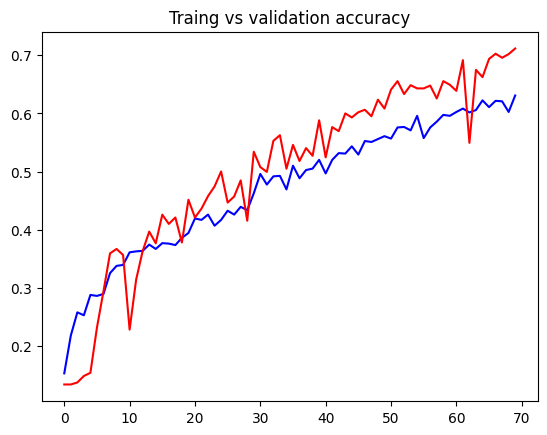

In [6]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='blue')
plt.plot(history.history['val_accuracy'],color='red')
plt.title('Traing vs validation accuracy')
plt.show()

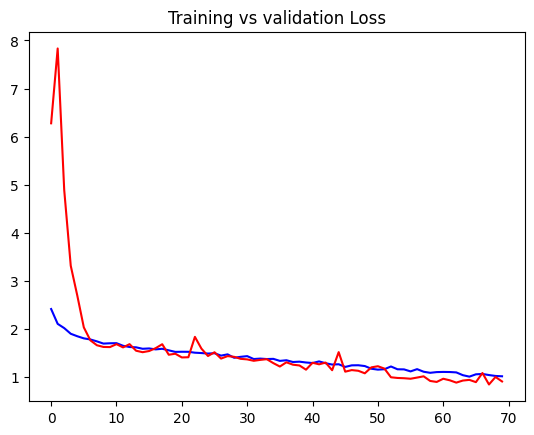

In [14]:
plt.plot(history.history['loss'],color='blue')
plt.plot(history.history['val_loss'],color='red')
plt.title('Training vs validation Loss')
plt.show()

In [7]:
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)

 

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [8]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.54      0.51      0.53        96
           1       0.72      0.74      0.73       192
           2       0.86      0.56      0.68       192
           3       0.78      0.62      0.69       192
           4       0.76      0.84      0.80       192
           5       0.90      0.64      0.75       192
           6       0.61      0.73      0.66       192
           7       0.62      0.95      0.75       192

    accuracy                           0.71      1440
   macro avg       0.72      0.70      0.70      1440
weighted avg       0.74      0.71      0.71      1440



In [9]:
model.save('Audio.keras')